# Stage 1 — Classical GCI Model (Vasicek Baseline)

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `00_overview.ipynb`
**Next:** → `02_quantum_encoding.ipynb`

---

This notebook builds the **classical baseline** that everything else in this project is trying to reproduce, first on a simulator and eventually on noisy hardware, using a quantum circuit. Before any qubit is touched, we need a precise, working, purely classical implementation of the credit-risk model — so that later we have exact numbers to validate the quantum circuit against.


## 1. What Is the GCI Model? (General Overview)

The **Gaussian Conditional-Independence (GCI) model** — also known in credit risk literature as the **Vasicek one-factor model** or the **Asymptotic Single Risk Factor (ASRF) model** — is one of the most widely used frameworks in banking for modeling *portfolio* credit risk. It underpins the Basel II/III regulatory capital formulas used by real banks today.

**The core idea:** individual borrowers don't default independently of each other. During a recession, many borrowers become more likely to default *at the same time*, because they're all exposed to the same macroeconomic conditions (interest rates, unemployment, GDP shocks, etc.). The GCI model captures this shared dependence using a single (or multiple) **latent systematic risk factor**.

- Each borrower has a **baseline (unconditional) probability of default**, denoted **p⁰**.
- All borrowers are jointly affected by a common, unobservable **systematic risk factor z** (think of it as "the state of the economy"), assumed to be standard normal: z ~ N(0, 1).
- Each borrower also has an **idiosyncratic (borrower-specific) risk component**, independent of everyone else's.
- **Correlation ρ (rho)** controls how much of a borrower's default risk is driven by the shared systematic factor vs. their own idiosyncratic risk.

**Crucially**, *conditional on* a fixed value of z, all borrowers' defaults become **independent** of each other — this is exactly what "Conditional Independence" in the model's name refers to, and it's what makes the model tractable: instead of simulating a complex web of pairwise correlations, we just need to know the distribution of z, and then defaults conditional on each z value are simple independent coin-flips.


## 2. Why We Use This Model in This Project

1. **It's the model the base paper uses.** The base paper (Ahmad et al., 2026) builds its entire quantum circuit around loading exactly this GCI/Vasicek uncertainty model onto qubits — so reproducing it classically first is a direct prerequisite for reproducing (and improving on) their quantum circuit.

2. **It's analytically simple but practically important.** It requires only two real numbers per asset (p⁰ and ρ) plus one shared latent variable (z), yet it's the actual formula underlying real-world regulatory capital calculations (Basel Accords). This makes it a realistic, non-toy target for quantum modeling.

3. **It naturally decomposes into something a quantum circuit can encode.** The conditional default probability PD(z) is a smooth, bounded function of a single latent variable z. As we'll see in the next notebook, a bounded probability like this maps naturally onto the probability of measuring a qubit in state \|1⟩ — which is exactly what makes this model "quantum encoding friendly."

4. **It gives us a ground truth to validate against.** Every later stage in this project (quantum training, transpilation, hardware/noise retuning, VaR extraction) is judged by *how close it gets back to this classical answer*. Without this notebook, there is nothing to compare the quantum circuit's output to.


## 3. Where This Fits in the Project Pipeline

This is **Stage 1 of 9**. Its output — the PD(z) curve, the chosen model parameters, and a classical Monte Carlo loss distribution/VaR — is used in **two later places**:

- **Stage 2 (Quantum Encoding):** the PD(z) formula derived here gets algebraically linearized and re-expressed as a quantum rotation angle.
- **Stage 9 (VaR & Fidelity Check):** the classical loss distribution and VaR computed here become the **ground-truth benchmark** that the final quantum-circuit output is compared against (via Hellinger fidelity and VaR match).

Everything in between (Stages 3–8) is about getting a *quantum circuit* to reproduce what this notebook computes *classically*.


## 4. The Mathematics

### 4.1 Where the formula comes from (brief derivation intuition)

Merton's structural model treats a firm as defaulting when its (normalized) asset value falls below a threshold. Under the one-factor Vasicek decomposition, a borrower's asset value return is split into a systematic component and an idiosyncratic component:

$$
X_k = \sqrt{\rho_k}\, z \;+\; \sqrt{1-\rho_k}\, \varepsilon_k
$$

where:
- $z \sim \mathcal{N}(0,1)$ is the **systematic factor**, shared by *all* borrowers (the "state of the economy"),
- $\varepsilon_k \sim \mathcal{N}(0,1)$ is the **idiosyncratic factor**, independent per borrower,
- $\rho_k \in [0,1]$ is the **asset correlation** of borrower/asset $k$ to the systematic factor.

Borrower $k$ defaults if $X_k$ falls below a threshold calibrated so that the *unconditional* default probability equals $p^0_k$, i.e. the threshold is $\Phi^{-1}(p^0_k)$. Conditioning on a fixed value of $z$ and solving for the probability that $X_k$ falls below that threshold gives the **GCI / Vasicek formula**:

### 4.2 The GCI Formula

$$
\mathrm{PD}_k(z) \;=\; \Phi\!\left( \frac{\Phi^{-1}(p^0_k) - \sqrt{\rho_k}\, z}{\sqrt{1-\rho_k}} \right)
$$

| Symbol | Meaning |
|---|---|
| $\mathrm{PD}_k(z)$ | Conditional probability of default of asset $k$, given systematic factor value $z$ |
| $\Phi(\cdot)$ | Standard normal cumulative distribution function (CDF) |
| $\Phi^{-1}(\cdot)$ | Inverse standard normal CDF (the quantile function) |
| $p^0_k$ | **Baseline (unconditional) default probability** of asset $k$ — its long-run average default rate |
| $\rho_k$ | **Asset correlation** — how strongly asset $k$'s default risk is tied to the systematic factor $z$ |
| $z$ | The **latent systematic risk factor**, $z \sim \mathcal{N}(0,1)$ — this is the variable that will later be loaded onto a quantum register |

**Reading the formula intuitively:**
- If $z$ is very negative (bad economy), the numerator $\Phi^{-1}(p^0_k) - \sqrt{\rho_k} z$ becomes *larger*, pushing $\mathrm{PD}_k(z)$ *up* — default becomes more likely during downturns. ✅ matches intuition.
- If $\rho_k = 0$, the formula collapses to $\mathrm{PD}_k(z) = \Phi(\Phi^{-1}(p^0_k)) = p^0_k$ — the asset is unaffected by the economy, defaults purely idiosyncratically.
- If $\rho_k \to 1$, the asset's default becomes almost entirely determined by $z$ — no idiosyncratic randomness left.

### 4.3 From a portfolio loss distribution to VaR

Given $N$ assets each with (LGD = loss given default) and the conditional independence property, the **portfolio loss conditional on $z$** is a sum of independent Bernoulli defaults:

$$
L(z) = \sum_{k=1}^{N} \mathrm{LGD}_k \cdot \mathbb{1}[\text{asset } k \text{ defaults} \mid z]
$$

Integrating (or, classically, Monte Carlo sampling) over the distribution of $z \sim \mathcal{N}(0,1)$ gives the **unconditional portfolio loss distribution**, from which we read off:

$$
\mathrm{VaR}_{\alpha} = \inf \{ L : \Pr(\text{Loss} \le L) \ge \alpha \}
$$

For this project (matching the base paper's use case), $\alpha = 95\%$.


## 5. Implementation

We now implement this classically in Python. We use the exact instance parameters used in the base paper's hardware demonstration (Section IV-C): a single asset, $p^0_1 = 0.25$, $\rho_1 = 0.027$.


In [1]:
import os
os.makedirs("results/figures", exist_ok=True)   # every output of this notebook goes into results/
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(42)

# ---- Model parameters (matching the base paper's hardware use-case, Sec. IV-C) ----
p0  = 0.25    # baseline (unconditional) default probability
rho = 0.027   # asset correlation / sensitivity to the systematic factor

def pd_given_z(z, p0=p0, rho=rho):
    """Gaussian Conditional-Independence / Vasicek conditional default probability.

    PD(z) = Phi( (Phi^-1(p0) - sqrt(rho) * z) / sqrt(1 - rho) )
    """
    numerator   = norm.ppf(p0) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

# sanity check: at z = 0 (average economy), PD(0) should be close to p0
print(f"p0 (baseline default prob.)      = {p0}")
print(f"rho (asset correlation)          = {rho}")
print(f"PD(z=0)  (should be close to p0) = {pd_given_z(0.0):.4f}")


p0 (baseline default prob.)      = 0.25
rho (asset correlation)          = 0.027
PD(z=0)  (should be close to p0) = 0.2471


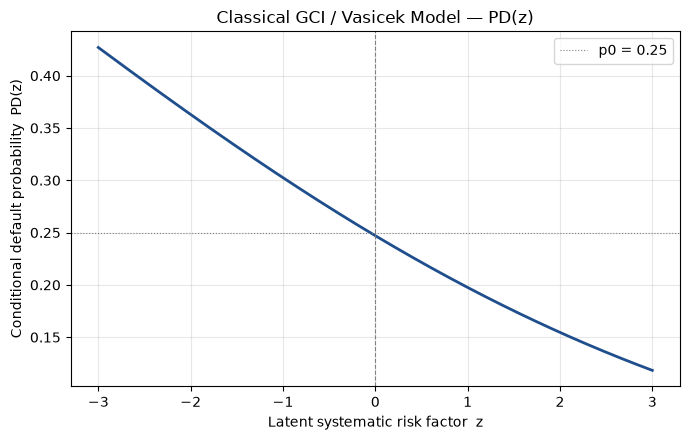

In [2]:
# ---- Visualize PD(z) across a range of the latent factor z ----
z_vals = np.linspace(-3, 3, 400)
pd_vals = pd_given_z(z_vals)

plt.figure(figsize=(7, 4.5))
plt.plot(z_vals, pd_vals, color='#1f4e8c', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(p0, color='gray', linestyle=':', linewidth=0.8, label=f'p0 = {p0}')
plt.xlabel('Latent systematic risk factor  z')
plt.ylabel('Conditional default probability  PD(z)')
plt.title('Classical GCI / Vasicek Model — PD(z)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/stage01_gci_pd_curve.png', dpi=150)
plt.show()


### 5.1 Discretizing z onto a grid

The quantum circuit (Stages 2–3) will represent $z$ using an $n$-qubit register, which can only take $2^n$ discrete basis-state values. So we need to discretize the continuous $z \sim \mathcal{N}(0,1)$ onto a grid **now**, matching whatever register size will be used later (2 qubits → 4 bins, 3 qubits → 8 bins), so that the classical and quantum versions of this model are directly comparable.

For each grid point $z(b)$ (indexed by basis state $b$), we assign a probability mass using the discretized normal density — this discretized histogram is exactly the **target distribution** that Stage 4 (classical training of the quantum circuit) will try to match.


In [3]:
def discretize_z(n_qubits, z_max=3.0):
    """Map the 2^n_qubits basis states to grid points in [-z_max, z_max],
    and assign each grid point a probability mass from the standard normal density.
    Mirrors Eq. (10) of the base paper.
    """
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    # affine map: basis index b -> grid point z(b) in [-z_max, z_max]
    z_grid = -z_max + (2 * z_max) * b / (n_bins - 1)

    # target probability mass function (discretized standard normal, un-normalized then normalized)
    raw = np.exp(-(z_grid ** 2) / 2)
    p_target = raw / raw.sum()
    return z_grid, p_target

for n_qubits in (2, 3):
    z_grid, p_target = discretize_z(n_qubits)
    print(f"--- {n_qubits}-qubit z-register ({2**n_qubits} bins) ---")
    for b, (zg, p) in enumerate(zip(z_grid, p_target)):
        print(f"  basis |{format(b, f'0{n_qubits}b')}>  ->  z = {zg:+.3f}   p = {p:.4f}   PD(z) = {pd_given_z(zg):.4f}")
    print()


--- 2-qubit z-register (4 bins) ---
  basis |00>  ->  z = -3.000   p = 0.0090   PD(z) = 0.4270
  basis |01>  ->  z = -1.000   p = 0.4910   PD(z) = 0.3025
  basis |10>  ->  z = +1.000   p = 0.4910   PD(z) = 0.1976
  basis |11>  ->  z = +3.000   p = 0.0090   PD(z) = 0.1183

--- 3-qubit z-register (8 bins) ---
  basis |000>  ->  z = -3.000   p = 0.0038   PD(z) = 0.4270
  basis |001>  ->  z = -2.143   p = 0.0344   PD(z) = 0.3719
  basis |010>  ->  z = -1.286   p = 0.1497   PD(z) = 0.3193
  basis |011>  ->  z = -0.429   p = 0.3121   PD(z) = 0.2701
  basis |100>  ->  z = +0.429   p = 0.3121   PD(z) = 0.2251
  basis |101>  ->  z = +1.286   p = 0.1497   PD(z) = 0.1846
  basis |110>  ->  z = +2.143   p = 0.0344   PD(z) = 0.1490
  basis |111>  ->  z = +3.000   p = 0.0038   PD(z) = 0.1183



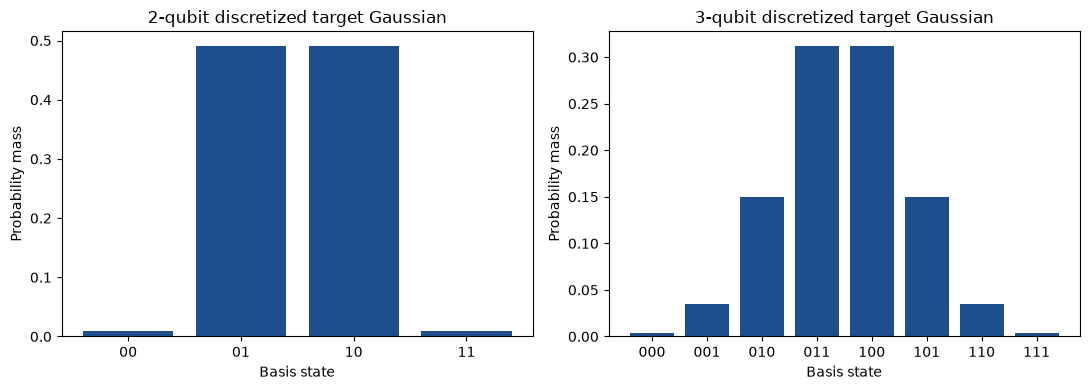

In [4]:
# ---- Plot the discretized target Gaussian histograms (2-qubit and 3-qubit) ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, n_qubits in zip(axes, (2, 3)):
    z_grid, p_target = discretize_z(n_qubits)
    labels = [format(b, f'0{n_qubits}b') for b in range(len(z_grid))]
    ax.bar(labels, p_target, color='#1f4e8c')
    ax.set_title(f'{n_qubits}-qubit discretized target Gaussian')
    ax.set_xlabel('Basis state')
    ax.set_ylabel('Probability mass')
plt.tight_layout()
plt.savefig('results/figures/stage01_gci_discretized_targets.png', dpi=150)
plt.show()


### 5.2 Classical Monte Carlo loss distribution and VaR (the benchmark)

This is the piece that will act as **ground truth for Stage 9**. We simulate the portfolio many times: for each simulation, draw a systematic factor $z$, compute the conditional default probability, sample whether the asset defaults, and record the resulting loss. Aggregating over many trials gives the classical loss distribution, from which we extract the 95% VaR.

We use a **single-asset** portfolio here (matching the base paper's 3-qubit hardware demonstration), with a Loss-Given-Default (LGD) of \$1000 assigned on default.


In [5]:
def classical_monte_carlo_var(p0=p0, rho=rho, lgd=1000, n_trials=2_000_000,
                               confidence=0.95, seed=42):
    """Classical Monte Carlo benchmark for the single-asset GCI model.
    Returns the loss distribution (as a PDF over unique loss values) and the VaR.
    """
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_trials)
    pd_z = pd_given_z(z, p0=p0, rho=rho)

    u = rng.uniform(size=n_trials)
    defaulted = u < pd_z
    losses = np.where(defaulted, lgd, 0)

    unique_losses, counts = np.unique(losses, return_counts=True)
    pdf = counts / n_trials
    cdf = np.cumsum(pdf)

    var_index = np.searchsorted(cdf, confidence)
    var = unique_losses[var_index]

    return unique_losses, pdf, cdf, var

unique_losses, pdf, cdf, var_95 = classical_monte_carlo_var()

print("Classical Monte Carlo baseline (single asset, LGD = $1000, 2,000,000 trials)")
print("-" * 70)
for L, p, c in zip(unique_losses, pdf, cdf):
    print(f"  Loss = ${L:<6}  P(Loss=L) = {p:.4f}   P(Loss<=L) = {c:.4f}")
print(f"\n95% Value at Risk (VaR):  ${var_95}")


Classical Monte Carlo baseline (single asset, LGD = $1000, 2,000,000 trials)
----------------------------------------------------------------------
  Loss = $0       P(Loss=L) = 0.7497   P(Loss<=L) = 0.7497
  Loss = $1000    P(Loss=L) = 0.2503   P(Loss<=L) = 1.0000

95% Value at Risk (VaR):  $1000


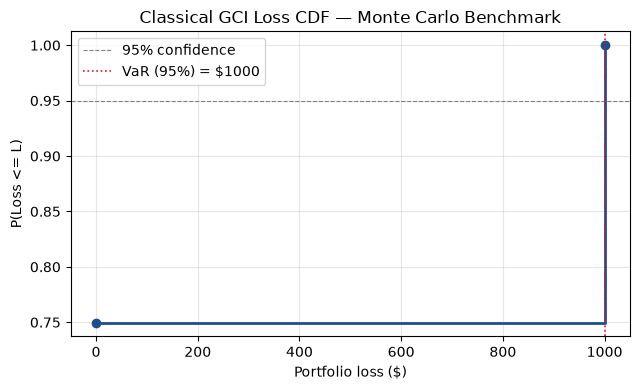

In [6]:
# ---- Plot the classical CDF, marking the 95% VaR ----
plt.figure(figsize=(6.5, 4))
plt.step(unique_losses, cdf, where='post', color='#1f4e8c', linewidth=2, marker='o')
plt.axhline(0.95, color='gray', linestyle='--', linewidth=0.8, label='95% confidence')
plt.axvline(var_95, color='crimson', linestyle=':', linewidth=1.2, label=f'VaR (95%) = ${var_95}')
plt.xlabel('Portfolio loss ($)')
plt.ylabel('P(Loss <= L)')
plt.title('Classical GCI Loss CDF — Monte Carlo Benchmark')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/stage01_gci_classical_cdf.png', dpi=150)
plt.show()


### 5.3 Saving the baseline for later stages

We persist the key outputs of this notebook to disk so that Stage 2 (quantum encoding) and Stage 9 (VaR & fidelity check) can load them without recomputing anything.


In [7]:
import json

baseline = {
    "model_parameters": {"p0": p0, "rho": rho, "lgd": 1000},
    "z_grids": {
        "2_qubit": {
            "z": discretize_z(2)[0].tolist(),
            "p_target": discretize_z(2)[1].tolist(),
        },
        "3_qubit": {
            "z": discretize_z(3)[0].tolist(),
            "p_target": discretize_z(3)[1].tolist(),
        },
    },
    "classical_monte_carlo": {
        "unique_losses": unique_losses.tolist(),
        "pdf": pdf.tolist(),
        "cdf": cdf.tolist(),
        "var_95": float(var_95),
    },
}

with open("results/classical_gci_baseline.json", "w") as f:
    json.dump(baseline, f, indent=2)

print("Saved -> results/classical_gci_baseline.json")
print(json.dumps(baseline["classical_monte_carlo"], indent=2))


Saved -> results/classical_gci_baseline.json
{
  "unique_losses": [
    0,
    1000
  ],
  "pdf": [
    0.7496935,
    0.2503065
  ],
  "cdf": [
    0.7496935,
    1.0
  ],
  "var_95": 1000.0
}


## 6. What This Stage Produces

By the end of this notebook we have, saved to `results/classical_gci_baseline.json`:

1. **The PD(z) function** — a working, tested Python implementation of the GCI/Vasicek conditional default probability.
2. **Discretized target Gaussian histograms** — for both a 2-qubit and a 3-qubit latent-factor register, ready to be the training target in Stage 4.
3. **A classical Monte Carlo loss distribution (PDF + CDF)** and the **95% VaR** — the ground-truth benchmark that the quantum pipeline (Stages 2–9) will be judged against.


## 7. What's Next

**Stage 2 — Quantum Encoding (`02_quantum_encoding.ipynb`):** The PD(z) formula derived here is a nonlinear function (a normal CDF of an affine function of $z$). Quantum circuits, however, most naturally encode probabilities as $\sin^2(\cdot)$ of a rotation angle (since $P(|1\rangle) = \sin^2(\theta/2)$ for a state rotated by an $R_y(\theta)$ gate from $|0\rangle$). So Stage 2 will:

- Linearize PD(z) within the region of interest so it can be written as $\mathrm{PD}(z) \approx \sin^2(\alpha z + \beta)$,
- Solve for the slope $\alpha$ and offset $\beta$ analytically,
- Show how this maps directly onto a parameterized $R_y(2(\alpha z + \beta))$ rotation gate — the first real "quantum" step of the project.

From there, Stage 3 builds the actual multi-qubit circuit (z-register + asset qubit), and Stage 4 trains it against the discretized target histograms produced in this notebook.




**The pattern to notice:** every odd conceptual step (define a target, encode it, train against it, validate against it) traces back to what this Stage 1 notebook produced. It's the foundation the rest of the repository is built on.

---
*Next: → `02_quantum_encoding.ipynb`*
